---
numbering:
  headings: false
---

(sec:pset_1_solution)=

# Solution of Problem Set 1

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize

## Exercise 1.1: Newton-Raphson with Finite Difference

In the lecture, we implemented the Newton-Raphson method for root finding,
which requires the derivative of the function.
At the end of the lecture, we briefly discussed how to approximate the derivative using
finite differences, which allows us to apply the Newton-Raphson method without
an analytical expression for the derivative.

**(a) Implement the Newton-Raphson method with a finite-difference approximation for the derivative. Use the `finite_difference` function from the lecture.**

In [22]:
def finite_difference(func, x, h=1e-6):
    return (func(x + h) - func(x - h)) / (2 * h)

In [23]:
def newton_raphson(func, x0, ftol=1e-10):
    x = x0
    converged = False

    while not converged:
        # SOLUTION-START
        fx = func(x)

        if abs(fx) < ftol:
            converged = True
        else:
            dfx = finite_difference(func, x)
            x = x - fx / dfx
        # SOLUTION-END

    return x

**(b) Calculate the molar volume of CO<sub>2</sub> at 275 K and 4.5 MPa using your implementation of the Newton-Raphson method with finite difference, applied to the Van der Waals equation. Print the solution in $\mathrm{l}\, \mathrm{mol^{-1}}$.**

In [24]:
R_CONST = 8.314462618   # J mol^-1 K^-1
A_PARAM = 0.3658        # Pa m^6 mol^-2
B_PARAM = 4.286e-5      # m^3 mol^-1


def vdw_residual(v_m):
    return (PRESSURE + A_PARAM / v_m**2) * (v_m - B_PARAM) - R_CONST * TEMP


# SOLUTION-START
TEMP = 275.0            # K
PRESSURE = 4.5e6        # Pa

guess = R_CONST * TEMP / PRESSURE
root = newton_raphson(vdw_residual, guess)
v_m_l_per_mol = root * 1e3
# SOLUTION-END

print('V_m:', v_m_l_per_mol, 'l mol^-1')

V_m: 0.34421275725902417 l mol^-1


## Exercise 1.2: Regression as an Optimisation Problem

A common task in data analysis is to fit a model to data, which is called *regression*.
Typically, we have a model with some parameters $\theta$ and a dataset of
input-output pairs $(x_i, y_i)$. The goal of regression is to find the parameters
$\theta$ that best explain the data.

We shall write the data, consisting of $N$ observations, as
:::{math}
:enumerated: false
\begin{align*}
  x &= (x_1, x_2, \ldots, x_N) \\
  y &= (y_1, y_2, \ldots, y_N)
\end{align*}
:::
and the model as
:::{math}
:enumerated: false
\hat{y}_i = f(\theta; x_i)\quad \text{for}\ i = 1, 2, \ldots, N \, .
:::

A common way to make the model fit the data as well as possible is to minimise
the sum of squared residuals, defined as
:::{math}
:enumerated: false
L(\theta; x, y) = \sum_{i=1}^N (y_i - \hat{y}_i)^2 = \sum_{i=1}^N (y_i - f(\theta; x_i))^2 \, ,
:::
leading to the so-called
[*least-squares*](https://en.wikipedia.org/wiki/Least_squares) method.

In this way, we have turned the regression problem into an optimisation problem,
where the objective function to be minimised is the loss function $L(\theta; x, y)$.


When a linear model is used, i.e., $f(\theta; x_i) = \theta_0 + \theta_1 x_i$
with $\theta = (\theta_0, \theta_1)$, the loss function can be implemented as

In [25]:
def linear_objective(theta, x, y):
    y_fit = theta[0] + theta[1] * x
    return np.sum((y_fit - y) ** 2)

The Lambert&ndash;Beer law is described by the equation
:::{math}
A = \varepsilon c d \, ,
:::
where $A$ is the absorbance, $\varepsilon$ is the molar extinction coefficient, 
$c$ is the concentration, and $d$ is the path length. Given a dataset of absorbance measurements at different concentrations, the extinction coefficient $\varepsilon$ 
can be determined by a linear regression of $A$ against $c$.

**(a) Determine the extinction coefficient $\varepsilon$ from the following dataset[^1], 
where the path length $d$ is 1 cm.**<br>
*Hint: Use `scipy.optimize.minimize` with `method='Nelder-Mead'` to minimise `linear_objective` and find the optimal parameters $\theta_0$ and $\theta_1$. 
Then calculate $\varepsilon = \theta_1 / d$ and print the result in $\mathrm{M^{-1} cm^{-1}}$.*

[^1]: The authors thank Dr. Hans-Christian Schmitt for providing the laboratory equipment used for these measurements.

In [26]:
concentrations = np.array([
    2.125, 4.250, 6.375, 8.500, 10.63, 12.75, 14.88, 17.00, 19.13, 21.25,
    23.38, 25.50, 27.63, 29.75, 31.88, 34.00, 36.13, 38.25, 40.38, 42.50,
])  # µM
absorbances = np.array([
    0.0572, 0.1391, 0.2049, 0.2754, 0.3420,
    0.4139, 0.4956, 0.5815, 0.6806, 0.7481,
    0.8242, 0.9130, 1.0043, 1.0809, 1.1511,
    1.2483, 1.3373, 1.4027, 1.4927, 1.5853,
])

res = minimize(
    # SOLUTION-START
    linear_objective,
    x0=np.array([0.0, 0.03]),
    method='Nelder-Mead',
    args=(concentrations, absorbances),
    # SOLUTION-END
)

# SOLUTION-START
theta0, theta1 = res.x
epsilon = theta1 * 1e6
# SOLUTION-END

print('epsilon:', epsilon, 'M^-1 cm^-1')

epsilon: 38000.58239391362 M^-1 cm^-1


Regression analysis is not limited to linear models. The concentration profile
of a first-order reaction, for example, can be described by the equation
:::{math}
:enumerated: false
c(t) = c_0 e^{-kt} \, ,
:::
where $c_0$ is the initial concentration, $k$ is the rate constant.

**(b) Implement the objective function for an exponential model with $\theta = (c_0, k)$.**

In [27]:
def exponential_objective(theta, x, y):
    # SOLUTION-START
    c0, k = theta
    y_fit = c0 * np.exp(-k * x)
    return np.sum((y_fit - y) ** 2)
    # SOLUTION-END

The decay of tris(oxalato)manganate(III) ion approximately follows first-order kinetics.
Consider the following absorbance measurements at 40 °C[^2].
Since the absorbance is proportional to the concentration, the rate constant $k$ can be determined by fitting an exponential model to the absorbance data,
*i.e.*, using $A(t) = A_0 e^{-kt}$.

**(c) Determine the rate constant $k$ using the exponential model.**<br>
*Hint: Use `scipy.optimize.minimize` with `method='Nelder-Mead'` to minimise `exponential_objective` and find the optimal parameters $\theta = (A_0, k)$.*

[^2]: The authors thank Ella Weiß and Noellie Zwaller for providing the data.

In [28]:
time = np.array([
    0.0, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0, 90.0,
    100.0, 110.0, 120.0, 130.0, 140.0, 150.0, 160.0, 170.0, 180.0,
    190.0, 200.0, 210.0, 220.0, 230.0, 240.0, 250.0, 260.0, 270.0,
    280.0, 290.0, 300.0,
])
absorbance = np.array([
    1.36045, 1.30614, 1.24810, 1.18582, 1.12329, 1.06024, 0.998690,
    0.939205, 0.881525, 0.825990, 0.773420, 0.723693, 0.676178,
    0.631285, 0.588940, 0.548783, 0.511026, 0.475465, 0.441880,
    0.410550, 0.380911, 0.353308, 0.327453, 0.303112, 0.280510,
    0.259181, 0.239575, 0.221209, 0.204020, 0.188091, 0.173065,
])

# SOLUTION-START
res_exp = minimize(
    exponential_objective,
    x0=np.array([1.5, 0.002]),
    method='Nelder-Mead',
    args=(time, absorbance),
)

a0_exp, k_exp = res_exp.x
# SOLUTION-END

print('a0_exp:', a0_exp)
print('k_exp:', k_exp, 's^-1')

a0_exp: 1.4310369584668052
k_exp: 0.006485830323281672 s^-1


The exponential model $A(t) = A_0 e^{-kt}$ can be linearised by taking the logarithm 
of both sides, leading to $\ln A(t) = \ln A_0 - kt$.

**(d) Determine the rate constant $k_\mathrm{lin}$ by performing a linear regression of 
$\ln A$ against $t$.**

In [29]:
log_absorbance = np.log(absorbance)

# SOLUTION-START
res_lin = minimize(
    linear_objective,
    x0=np.array([0.0, -0.001]),
    method='Nelder-Mead',
    args=(time, log_absorbance),
)

theta0, theta1 = res_lin.x
a0_lin = np.exp(theta0)
k_lin = -theta1
# SOLUTION-END

print('a0_lin:', a0_lin)
print('k_lin:', k_lin, 's^-1')


a0_lin: 1.5039071819256657
k_lin: 0.006980940764165716 s^-1


The two rate constants $k$ and $k_\mathrm{lin}$ are not exactly the same, 
because the linearisation changes the error structure of the data.

**(e) Plot the original data and the fitted curves from both methods on the same graph.
Add appropriate labels and legends.**

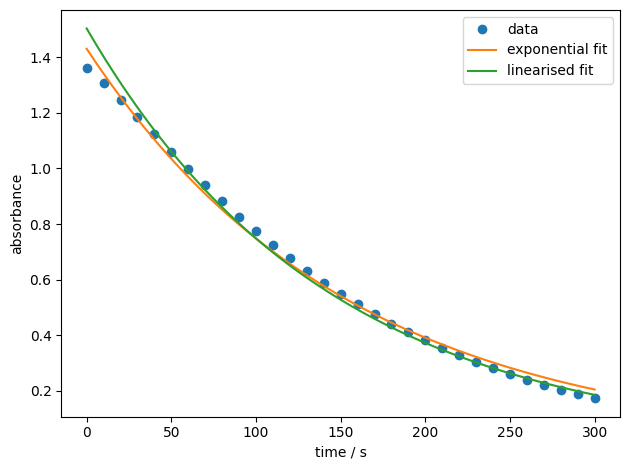

In [30]:
time_plot = np.linspace(np.min(time), np.max(time), 100)

plt.plot(time, absorbance, 'o', label='data')

# SOLUTION-START
plt.plot(
    time_plot,
    a0_exp * np.exp(-k_exp * time_plot),
    label='exponential fit',
)
plt.plot(
    time_plot,
    a0_lin * np.exp(-k_lin * time_plot),
    label='linearised fit',
)
plt.xlabel('time / s')
plt.ylabel('absorbance')
plt.legend()
plt.tight_layout()
# SOLUTION-END

## Exercise 1.3: Solving a System of ODEs

There are far more chemical reactions than simple first-order kinetics.
One class of chemically interesting and aesthetically pleasing reactions consists of
oscillating reactions, which can be approximately described by the
[Brusselator](https://en.wikipedia.org/wiki/Brusselator),
a system of two coupled first-order nonlinear ODEs:
:::{math}
:label: eq:brusselator
\begin{aligned}
\frac{\mathrm{d}x}{\mathrm{d}t} &= A + x^2 y - (B + 1)x \\
\frac{\mathrm{d}y}{\mathrm{d}t} &= Bx - x^2 y
\end{aligned}
:::
with parameters $A$ and $B$.


**(a) Implement the derivative function `dydt_brusselator(t, y_vec)` that 
returns the derivatives $\mathrm{d}x/\mathrm{d}t$ and $\mathrm{d}y/\mathrm{d}t$ as 
a NumPy array.**<br>
*Hint 1: The code uses `y_vec` for the full state vector. Although the variables in the equations are called $x(t)$ and $y(t)$, the vector is stored as* `y_vec = [x(t), y(t)]`.<br>
*Hint 2: You do not need to modify the Euler implementation from the lecture. Since it already works with NumPy arrays, it can also propagate the two-component state vector returned by this derivative function.*

In [31]:
A_PARAM = 1.0
B_PARAM = 3.0


def dydt_brusselator(t, y_vec):
    # SOLUTION-START
    x_val, y_val = y_vec

    dxdt = A_PARAM + x_val**2 * y_val - (B_PARAM + 1.0) * x_val
    dydt = B_PARAM * x_val - x_val**2 * y_val
    # SOLUTION-END
    
    return np.array([dxdt, dydt])


**(b) Solve the system of ODEs using the Euler method we implemented in the lecture
with $t \in [0, 50]$ with the initial conditions $x(0) = 1.5$ and $y(0) = 3.0$. 
Use three different step sizes: 0.05, 0.20, and 0.40.**<br>
*Hint: If you see runtime warnings for the larger step sizes, this can be expected here and does not necessarily mean that your implementation is wrong.*

In [32]:
def euler_step(dydt, t_n, y_n, h):
    y_np1 = y_n + h * dydt(t_n, y_n)
    return y_np1


def euler_method(dydt, t0, y0, h, nsteps):
    ndim = len(y0)

    t_grid = t0 + np.arange(0, nsteps + 1) * h
    y_grid = np.zeros((ndim, nsteps + 1))
    y_grid[:, 0] = y0

    for i in range(nsteps):
        y_grid[:, i + 1] = euler_step(dydt, t_grid[i], y_grid[:, i], h)

    return t_grid, y_grid

In [33]:
Y0 = np.array([1.5, 3.0])
T0 = 0.0
T_MAX = 50.0

# SOLUTION-START
STEP1 = 0.05
STEP2 = 0.20
STEP3 = 0.40

t_step1, y_step1 = euler_method(dydt_brusselator, T0, Y0, STEP1, int(T_MAX / STEP1))
t_step2, y_step2 = euler_method(dydt_brusselator, T0, Y0, STEP2, int(T_MAX / STEP2))
t_step3, y_step3 = euler_method(dydt_brusselator, T0, Y0, STEP3, int(T_MAX / STEP3))
# SOLUTION-END


/var/folders/x7/yn8qjbbd65561bk1zj5_mghh0000gn/T/ipykernel_89749/517849631.py:9: RuntimeWarning: overflow encountered in scalar power
  dxdt = A_PARAM + x_val**2 * y_val - (B_PARAM + 1.0) * x_val
/var/folders/x7/yn8qjbbd65561bk1zj5_mghh0000gn/T/ipykernel_89749/517849631.py:10: RuntimeWarning: overflow encountered in scalar power
  dydt = B_PARAM * x_val - x_val**2 * y_val
/var/folders/x7/yn8qjbbd65561bk1zj5_mghh0000gn/T/ipykernel_89749/3124080442.py:2: RuntimeWarning: invalid value encountered in add
  y_np1 = y_n + h * dydt(t_n, y_n)
/var/folders/x7/yn8qjbbd65561bk1zj5_mghh0000gn/T/ipykernel_89749/517849631.py:9: RuntimeWarning: overflow encountered in scalar multiply
  dxdt = A_PARAM + x_val**2 * y_val - (B_PARAM + 1.0) * x_val
/var/folders/x7/yn8qjbbd65561bk1zj5_mghh0000gn/T/ipykernel_89749/517849631.py:10: RuntimeWarning: overflow encountered in scalar multiply
  dydt = B_PARAM * x_val - x_val**2 * y_val


**(c) Plot $x(t)$ for the three different step sizes on the same graph.
Add appropriate labels and legends. 
Use [`matplotlib.pyplot.ylim`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.ylim.html) to set appropriate y-axis limits.**

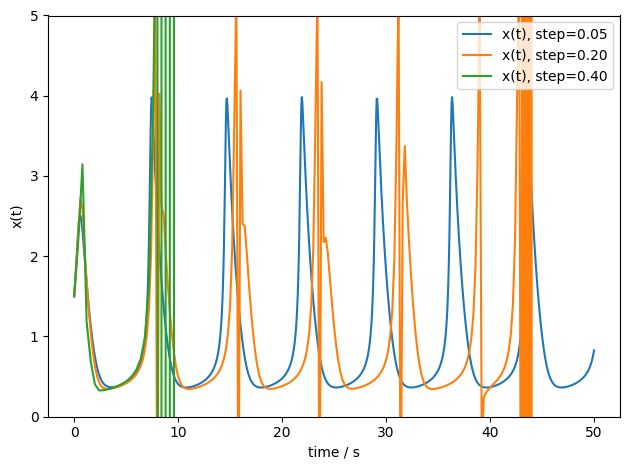

In [34]:
# SOLUTION-START
plt.plot(t_step1, y_step1[0, :], label='x(t), step=0.05')
plt.plot(t_step2, y_step2[0, :], label='x(t), step=0.20')
plt.plot(t_step3, y_step3[0, :], label='x(t), step=0.40')
plt.xlabel('time / s')
plt.ylabel('x(t)')
plt.ylim(0.0, 5.0)
plt.legend()
plt.tight_layout()
# SOLUTION-END

**(d) Solve the system of ODEs in (b) using `scipy.integrate.solve_ivp` 
with `method='RK45'`. 
Compare the number of function evaluations for the Euler method with the smallest 
step size and the RK45 method.
Plot the solution of $x(t)$ of these two methods on the same graph.
Add appropriate labels and legends.**

Number of function evaluations (Euler, step=0.05): 1000
Number of function evaluations (RK45): 932


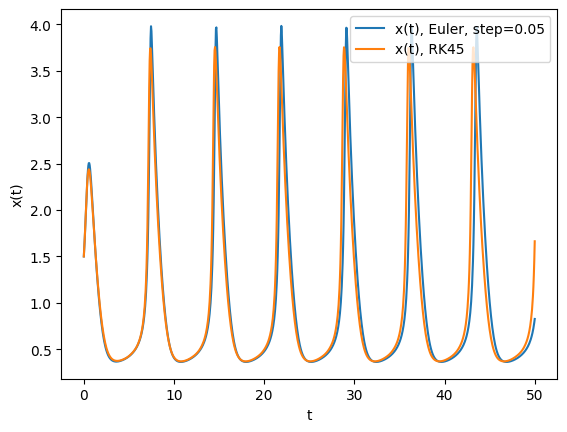

In [35]:
# SOLUTION-START
res_ivp = solve_ivp(
    dydt_brusselator,
    t_span=(T0, T_MAX),
    y0=Y0,
    t_eval=t_step1,
    method='RK45',
)

print('Number of function evaluations (Euler, step=0.05):', len(t_step1) - 1)
print('Number of function evaluations (RK45):', res_ivp.nfev)

plt.plot(t_step1, y_step1[0, :], label='x(t), Euler, step=0.05')
plt.plot(t_step1, res_ivp.y[0, :], label='x(t), RK45')
plt.xlabel('t')
plt.ylabel('x(t)')
plt.legend()
plt.show()
# SOLUTION-END

<br>